In [7]:
import numpy as np
import seaborn as sns
import pandas as pd

# Voting Classifier

In [8]:
df = sns.load_dataset("iris")

In [9]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [10]:
# label encode the species column
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

In [11]:
df['species'] = encoder.fit_transform(df['species'])

In [12]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


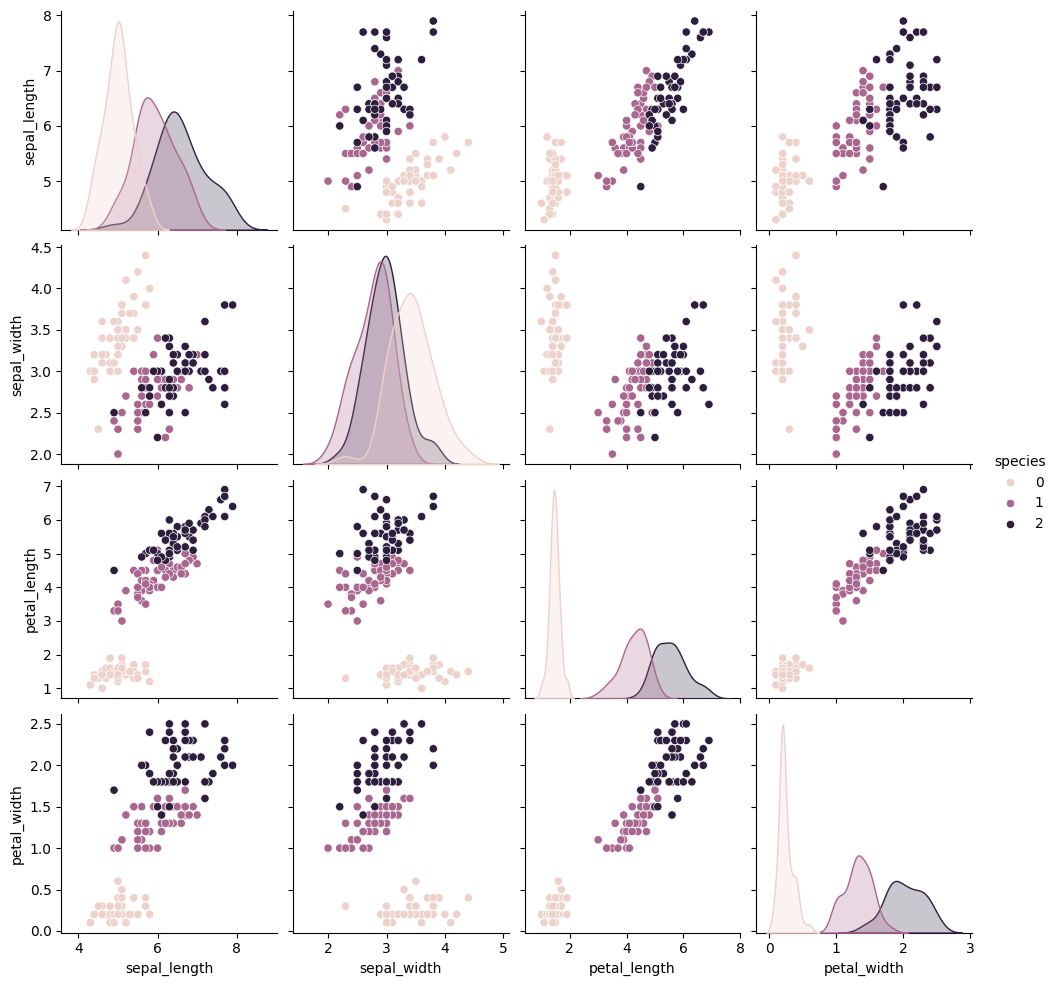

In [13]:
sns.pairplot(df, hue='species')

In [15]:
new_df = df[df['species'] != 0][['sepal_length', 'sepal_width', 'species']]

In [16]:
new_df.head()

,sepal_length,sepal_width,species
50,7.0,3.2,1
51,6.4,3.2,1
52,6.9,3.1,1
53,5.5,2.3,1
54,6.5,2.8,1


In [17]:
new_df.shape

(100, 3)

In [19]:
X = df.iloc[:,:2]
y = df.iloc[:,-1]

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

In [21]:
clf1 = LogisticRegression()
clf2 = KNeighborsClassifier()
clf3 = RandomForestClassifier()

In [22]:
estimators= [('lr', clf1), ('knn', clf2), ('rf', clf3)]

In [24]:
for estimator in estimators:
    scores = cross_val_score(estimator[1], X, y, cv=10, scoring='accuracy')
    print(f"{estimator[0]}: {np.mean(scores)}")

lr: 0.8066666666666669
knn: 0.76
rf: 0.7


In [25]:
from sklearn.ensemble import VotingClassifier

# Hard Voting

In [26]:
vc = VotingClassifier(estimators=estimators, voting='hard')
x = cross_val_score(vc,X,y,cv=10,scoring='accuracy')
print(f"voting classifier: {np.mean(x)}")

voting classifier: 0.7733333333333333


# Soft Voting

In [27]:
vc1 = VotingClassifier(estimators=estimators, voting='soft')
x = cross_val_score(vc,X,y,cv=10,scoring='accuracy')
print(f"voting classifier: {np.mean(x)}")

voting classifier: 0.7666666666666667


# from above we can understand that logistic regression is the best suited model for this data

# Weighted Voting

In [28]:
for i in range(1,4):
    for j in range(1,4):
        for k in range(1,4):
            vc = VotingClassifier(estimators=estimators, voting='soft', weights=[i,j,k])
            x = cross_val_score(vc,X,y,cv=10,scoring='accuracy')
            print(f"voting classifier with weights {i},{j},{k}: {np.mean(x)}")

voting classifier with weights 1,1,1: 0.7733333333333334
voting classifier with weights 1,1,2: 0.7533333333333333
voting classifier with weights 1,1,3: 0.7333333333333333
voting classifier with weights 1,2,1: 0.7533333333333333
voting classifier with weights 1,2,2: 0.76
voting classifier with weights 1,2,3: 0.7533333333333333
voting classifier with weights 1,3,1: 0.7533333333333333
voting classifier with weights 1,3,2: 0.7466666666666667
voting classifier with weights 1,3,3: 0.7466666666666667
voting classifier with weights 2,1,1: 0.7733333333333333
voting classifier with weights 2,1,2: 0.7666666666666667
voting classifier with weights 2,1,3: 0.7333333333333333
voting classifier with weights 2,2,1: 0.7733333333333333
voting classifier with weights 2,2,2: 0.7666666666666667
voting classifier with weights 2,2,3: 0.76
voting classifier with weights 2,3,1: 0.7666666666666667
voting classifier with weights 2,3,2: 0.76
voting classifier with weights 2,3,3: 0.76
voting classifier with weights

# classifiers of same algo

In [30]:
from sklearn.svm import SVC
from sklearn.datasets import make_classification

In [35]:
X, y = make_classification(n_samples=1000, n_features=20, n_informative=15, n_redundant=5, random_state=2)

svm1 = SVC(kernel='poly',probability=True,degree=1)  
svm2 = SVC(kernel='poly',probability=True,degree=2)  
svm3 = SVC(kernel='poly',probability=True,degree=3)  
svm4 = SVC(kernel='poly',probability=True,degree=4)  
svm5 = SVC(kernel='poly',probability=True,degree=5)  

estimators = [('svm1', svm1), ('svm2', svm2), ('svm3', svm3), ('svm4', svm4), ('svm5', svm5)]

for estimator in estimators:
    x = cross_val_score(estimator[1],X,y,cv=10,scoring='accuracy')
    print(f"{estimator[0]}: {np.mean(x)}")

svm1: 0.8540000000000001
svm2: 0.8530000000000001
svm3: 0.8939999999999999
svm4: 0.8089999999999999
svm5: 0.8639999999999999


In [36]:
vc1 = VotingClassifier(estimators=estimators, voting='soft')
x = cross_val_score(vc1,X,y,cv=10,scoring='accuracy')
print(f"voting classifier: {np.mean(x)}")

voting classifier: 0.9260000000000002
